# Phase locking

In this example, we demonstrate calculation of various phase locking metrics.

In [8]:
import os, sys
sys.path.append("../")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

from burst_toolbox.coupling import phase_locking_value_spectr, phase_locking_value_hilb
from burst_toolbox.stats import cluster_test_period

LFP_COLS = [f"LFP_{k}" for k in range(6499)]
BASELINE = (100, 900)

In [9]:
data = pd.read_csv(os.path.join("sample_data", "MU16.csv"))
data.head()

,patient,region,channel,trial_idx,LFP_0,LFP_1,LFP_2,LFP_3,LFP_4,LFP_5,...,LFP_6489,LFP_6490,LFP_6491,LFP_6492,LFP_6493,LFP_6494,LFP_6495,LFP_6496,LFP_6497,LFP_6498
0,MU16,LMFG,47,2,-60.586345,-61.003159,-56.932662,-49.502180,-57.041221,-50.611589,...,-22.416510,-19.159159,-31.267181,-24.738918,-36.600229,-32.127004,-28.065220,-26.732139,-31.661379,-21.543727
1,MU16,LMFG,47,3,70.637892,70.961432,60.612772,64.904897,61.675591,56.262496,...,-75.301535,-67.050140,-66.253000,-57.827647,-60.655502,-66.283112,-49.654750,-36.654182,-44.326227,-47.930041
2,MU16,LMFG,47,4,106.745603,95.213250,102.347220,94.459910,102.302446,93.481191,...,-3.919453,1.671527,3.907104,5.109215,4.066670,-6.005560,-9.228409,-4.949366,-10.088047,-11.581020
3,MU16,LMFG,47,5,-141.957212,-142.918853,-151.615530,-139.499856,-139.383692,-137.511779,...,-105.997811,-109.009809,-106.829899,-117.390465,-115.232323,-109.082471,-119.630475,-115.983875,-129.566979,-127.320677
4,MU16,LMFG,47,6,26.043050,41.416215,35.086903,36.075132,38.714519,39.923637,...,-78.135456,-80.281772,-72.660984,-69.412884,-61.186371,-61.112856,-64.577571,-58.155731,-60.150052,-54.026011


In [10]:
print(f"ROIs and channels:")
data[['region', 'channel']].drop_duplicates(ignore_index = True)

ROIs and channels:


,region,channel
0,LMFG,47
1,LMFG,60
2,LH,2
3,LH,10


## Phase locking value (over trials, spectrogram method)

In [11]:
plvs = []

for channel1 in [47, 60]:
    for channel2 in [2, 10]:

        # Match trials
        channel1_trials = set(data[data["channel"] == channel1]["trial_idx"])
        channel2_trials = set(data[data["channel"] == channel2]["trial_idx"])
        common_trials = channel1_trials.intersection(channel2_trials)

        channel1_LFP = data[(data["channel"] == channel1) & (data["trial_idx"].isin(common_trials))].sort_values("trial_idx", ascending = True)[LFP_COLS].to_numpy()
        channel2_LFP = data[(data["channel"] == channel2) & (data["trial_idx"].isin(common_trials))].sort_values("trial_idx", ascending = True)[LFP_COLS].to_numpy()
        assert(channel1_LFP.shape == channel2_LFP.shape)

        f, t, plv = phase_locking_value_spectr(LFP = np.stack([channel1_LFP, channel2_LFP]), dim = "trial")
        plvs.append(plv)
    
plvs = np.array(plvs)
plvs.shape # (n_channel, n_freq, t)

(4, 129, 28)

Text(0.5, 1.0, 'PLV between LMFG and LH')

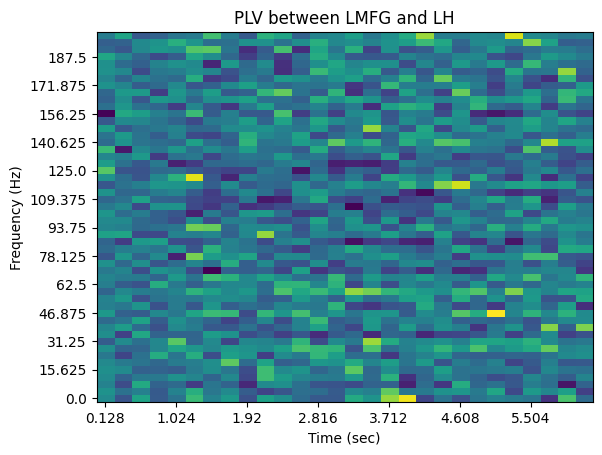

In [ ]:
fig, ax = plt.subplots(1, 1)
ca = ax

# Baseline-correct
plvs = plvs - np.nanmean(plvs[:, :, 0 : len(t[t < 1])], axis = -1, keepdims = True)

ca.imshow(np.nanmean(plvs, axis = 0)[f < 200], origin = "lower", aspect = "auto", interpolation = "none")
ca.set_yticks(range(len(f[f < 200]))[::4], labels = f[f < 200][::4])
ca.set_xticks(range(len(t))[::4], t[::4])

ca.set_ylabel("Frequency (Hz)")
ca.set_xlabel("Time (sec)")
ca.set_title("PLV between LMFG and LH")

## Phase locking value (over trials, Hilbert method)

In [16]:
plvs = []

for channel1 in [47, 60]:
    for channel2 in [2, 10]:

        # Match trials
        channel1_trials = set(data[data["channel"] == channel1]["trial_idx"])
        channel2_trials = set(data[data["channel"] == channel2]["trial_idx"])
        common_trials = channel1_trials.intersection(channel2_trials)

        channel1_LFP = data[(data["channel"] == channel1) & (data["trial_idx"].isin(common_trials))].sort_values("trial_idx", ascending = True)[LFP_COLS].to_numpy()
        channel2_LFP = data[(data["channel"] == channel2) & (data["trial_idx"].isin(common_trials))].sort_values("trial_idx", ascending = True)[LFP_COLS].to_numpy()
        assert(channel1_LFP.shape == channel2_LFP.shape)

        plv = phase_locking_value_hilb(LFP = np.stack([channel1_LFP, channel2_LFP]), phase_freq_band = np.array([12, 30]))
        plvs.append(plv)
    
plvs = np.array(plvs)
plvs.shape # (n_channel, n_freq, t)

(4, 6499)

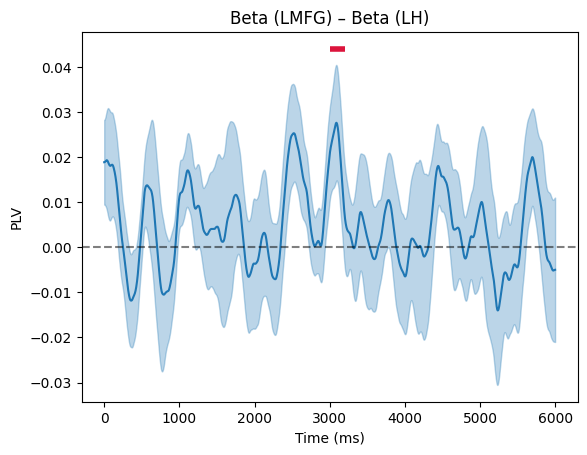

In [18]:
fig, ax = plt.subplots(1, 1)
ca = ax

cutoff = 6000 # (ms)

# Baseline-correct
plvs = plvs - np.nanmean(plvs[:, BASELINE[0] : BASELINE[1]])
plvs = plvs[:, :cutoff]

avg_plv = np.nanmean(plvs, axis = 0)
sem_plv = np.nanstd(plvs, axis = 0) / np.sqrt(len(plvs))
T = len(avg_plv)

ca.plot(
    range(T), 
    uniform_filter1d(avg_plv, 200),
    color = "tab:blue"
    )
ca.fill_between(
    range(T), 
    uniform_filter1d(avg_plv - sem_plv, 200), 
    uniform_filter1d(avg_plv + sem_plv, 200),
    color = "tab:blue",
    alpha = 0.3
    )

ca.set_xlabel("Time (ms)")
ca.set_ylabel("PLV")
ca.set_title("Beta (LMFG) – Beta (LH)")
ca.axhline(0, ls = "--", color = "black", alpha = 0.5)

# Cluster-test
step = 100
win_range = np.arange(0, len(LFP_COLS), step)
clusters = cluster_test_period(
    sample = plvs,
    period = BASELINE,
    win_range = win_range,
    win_size = 200
)

if len(clusters) > 0:
    yval = ca.get_ylim()[1]
    for tstat_id, period in enumerate(win_range):
        if (period < 100) or (period > 6200): continue
        if clusters[tstat_id] == 0: continue
        ca.hlines(yval, period, period + step, color = 'crimson', linewidth = 4)